In [1]:
# Bibliotheken importieren
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import ClassificationMetric
from aif360.algorithms.preprocessing import Reweighing

# Daten laden
X_train = pd.read_csv('../data/X_train.csv')
X_test = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test = pd.read_csv('../data/y_test.csv').squeeze()
sex_train = pd.read_csv('../data/sex_train.csv').squeeze()
sex_test = pd.read_csv('../data/sex_test.csv').squeeze()

print("Daten geladen.")

pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[inFairness]'


Daten geladen.


In [3]:
 # AIF360 Trainingsdatensatz vorbereiten
train_df = X_train.copy()
train_df['income'] = y_train.values
train_df['sex'] = sex_train.values

dataset_train = BinaryLabelDataset(
    df=train_df,
    label_names=['income'],
    protected_attribute_names=['sex']
)

# Reweighing anwenden
rw = Reweighing(
    unprivileged_groups=[{'sex': 0}],
    privileged_groups=[{'sex': 1}]
)
dataset_train_rw = rw.fit_transform(dataset_train)

print("Reweighing abgeschlossen.")
print("Beispiel Gewichte:", dataset_train_rw.instance_weights[:5])


Reweighing abgeschlossen.
Beispiel Gewichte: [1.09449781 0.85133806 0.85133806 0.85133806 1.09449781]


In [5]:
# Modell mit Reweighing trainieren
rf_model_rw = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model_rw.fit(
    X_train,
    y_train,
    sample_weight=dataset_train_rw.instance_weights
)

y_pred_rw = rf_model_rw.predict(X_test)

print("Modell trainiert.")
print("Accuracy nach Reweighing:", round(accuracy_score(y_test, y_pred_rw), 4))

Modell trainiert.
Accuracy nach Reweighing: 0.8445


In [7]:
# Fairness-Metriken nach Reweighing berechnen
test_df = X_test.copy()
test_df['income'] = y_test.values
test_df['sex'] = sex_test.values

pred_df_rw = X_test.copy()
pred_df_rw['income'] = y_pred_rw
pred_df_rw['sex'] = sex_test.values

dataset_true = BinaryLabelDataset(
    df=test_df,
    label_names=['income'],
    protected_attribute_names=['sex']
)

dataset_pred_rw = BinaryLabelDataset(
    df=pred_df_rw,
    label_names=['income'],
    protected_attribute_names=['sex']
)

metric_rw = ClassificationMetric(
    dataset_true,
    dataset_pred_rw,
    unprivileged_groups=[{'sex': 0}],
    privileged_groups=[{'sex': 1}]
)

sp_rw = metric_rw.statistical_parity_difference()
di_rw = metric_rw.disparate_impact()
eo_tpr_rw = metric_rw.true_positive_rate_difference()
eo_fpr_rw = metric_rw.false_positive_rate_difference()

print("Statistical Parity Difference:", round(sp_rw, 4))
print("Disparate Impact Ratio:", round(di_rw, 4))
print("Equalized Odds — TPR Difference:", round(eo_tpr_rw, 4))
print("Equalized Odds — FPR Difference:", round(eo_fpr_rw, 4))

Statistical Parity Difference: -0.176
Disparate Impact Ratio: 0.3316
Equalized Odds — TPR Difference: -0.0584
Equalized Odds — FPR Difference: -0.0836


In [9]:
# Vergleich vor und nach Reweighing
results_comparison = pd.DataFrame({
    'Metrik': [
        'Statistical Parity Difference',
        'Disparate Impact Ratio',
        'Equalized Odds TPR Difference',
        'Equalized Odds FPR Difference'
    ],
    'Baseline': [-0.1822, 0.3252, -0.0699, -0.0877],
    'Nach Reweighing': [sp_rw, di_rw, eo_tpr_rw, eo_fpr_rw],
})

results_comparison['Verbesserung'] = (
    results_comparison['Nach Reweighing'] - results_comparison['Baseline']
).round(4)

results_comparison.to_csv('../results/tables/fairness_comparison.csv', index=False)
print(results_comparison)


                          Metrik  Baseline  Nach Reweighing  Verbesserung
0  Statistical Parity Difference   -0.1822        -0.175983        0.0062
1         Disparate Impact Ratio    0.3252         0.331634        0.0064
2  Equalized Odds TPR Difference   -0.0699        -0.058412        0.0115
3  Equalized Odds FPR Difference   -0.0877        -0.083613        0.0041


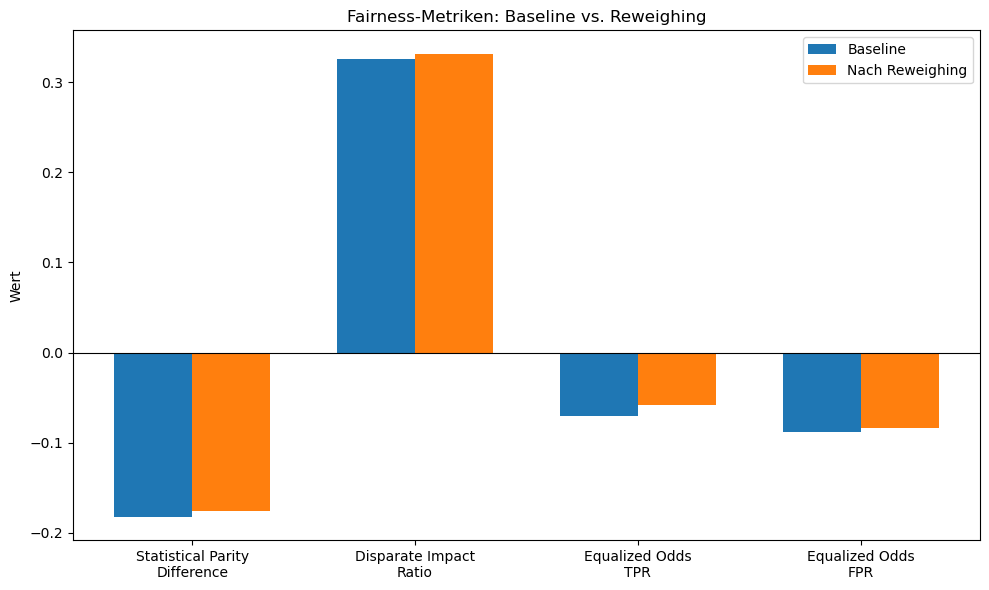

Gespeichert.


In [11]:
# Visualisierung Vergleich
import matplotlib.pyplot as plt
import numpy as np

metriken = ['Statistical Parity\nDifference', 'Disparate Impact\nRatio', 
            'Equalized Odds\nTPR', 'Equalized Odds\nFPR']
baseline_vals = [-0.1822, 0.3252, -0.0699, -0.0877]
rw_vals = [sp_rw, di_rw, eo_tpr_rw, eo_fpr_rw]

x = np.arange(len(metriken))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, baseline_vals, width, label='Baseline')
ax.bar(x + width/2, rw_vals, width, label='Nach Reweighing')

ax.set_xticks(x)
ax.set_xticklabels(metriken)
ax.set_ylabel('Wert')
ax.set_title('Fairness-Metriken: Baseline vs. Reweighing')
ax.legend()
ax.axhline(y=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('../results/figures/fairness_comparison.png', dpi=150)
plt.show()
print("Gespeichert.")